In [1]:
import torch
torch.set_num_threads(1)

from IPython.display import Audio
from pprint import pprint

In [2]:
# download example
torch.hub.download_url_to_file('https://models.silero.ai/vad_models/en.wav', 'en_example.wav')

model, utils = torch.hub.load(repo_or_dir='snakers4/silero-vad',
                              model='silero_vad',
                              force_reload=True)

100%|██████████| 1.83M/1.83M [00:01<00:00, 1.01MB/s]


Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /home/fm-pc-lt-278/.cache/torch/hub/master.zip


In [11]:
sampling_rate = 16000 # also accepts 8000

In [4]:
(get_speech_timestamps,
 _, read_audio,
 *_) = utils

In [41]:
import os

In [64]:
import matplotlib.pyplot as plt


def plot_multi_speaker_timeline(
    speakers_segments,
    speaker_names,
    sample_rate=16000,
    audio_duration_samples=None,
):

    assert len(speakers_segments) == len(speaker_names), \
        "speakers_segments and speaker_names must have same length"

    # Infer total duration if not given
    if audio_duration_samples is None:
        audio_duration_samples = max(
            seg["end"]
            for speaker in speakers_segments
            for seg in speaker
        )

    audio_duration_sec = audio_duration_samples / sample_rate

    fig, ax = plt.subplots(figsize=(15, max(4, len(speakers_segments) * 0.8)))

    # Assign each speaker a vertical lane
    y_positions = {name: i for i, name in enumerate(reversed(speaker_names))}

    def draw_segments(segments, y):
        for seg in segments:
            start_sec = seg["start"] / sample_rate
            end_sec = seg["end"] / sample_rate
            duration = end_sec - start_sec

            ax.broken_barh(
                [(start_sec, duration)],
                (y - 0.35, 0.7)
            )

            ax.text(
                start_sec + duration / 2,
                y,
                f"{duration:.2f}s",
                ha="center",
                va="center",
                fontsize=8,
                color="white",
                fontweight="bold",
            )

    # Plot all speakers
    for name, segments in zip(speaker_names, speakers_segments):
        draw_segments(segments, y_positions[name])

    # Formatting
    ax.set_ylim(-1, len(speaker_names))
    ax.set_xlim(0, audio_duration_sec)

    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(list(y_positions.keys()))

    ax.set_xlabel("Time (seconds)")
    ax.set_title("Multi-Speaker Speech Activity Timeline (Silero VAD)")
    ax.grid(axis="x", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

In [66]:
def chunk_interview(diarized_audio_path):
    audios = [os.path.join(diarized_audio_path, wav_file) for wav_file in os.listdir(diarized_audio_path) if wav_file.endswith(".wav")]

    timestamps = []
    for id, audio in enumerate(audios):
        print("Applying VAD on audio: ", id)
        wav = read_audio(audio, sampling_rate=sampling_rate)
        speech_timestamps = get_speech_timestamps(wav, model, sampling_rate=sampling_rate)
        timestamps.append(speech_timestamps)
        print("Processed audio: ", id)

    
    plot_multi_speaker_timeline(timestamps, ["Interviewer", "Candidate"])
    return timestamps

Applying VAD on audio:  0
Processed audio:  0
Applying VAD on audio:  1
Processed audio:  1


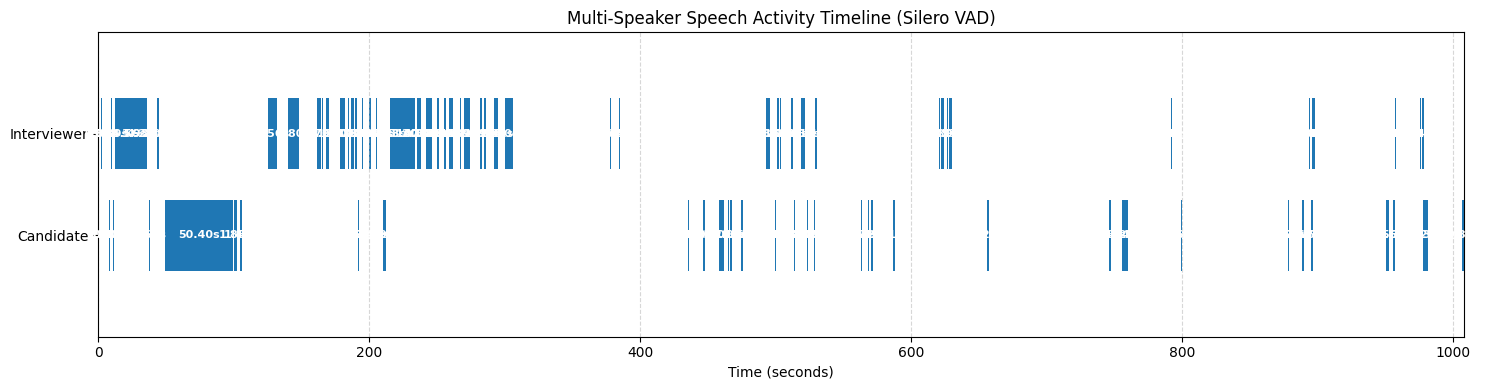

In [72]:
timestamps_1 = chunk_interview("diarization_output/sample1/")

Applying VAD on audio:  0
Processed audio:  0
Applying VAD on audio:  1
Processed audio:  1


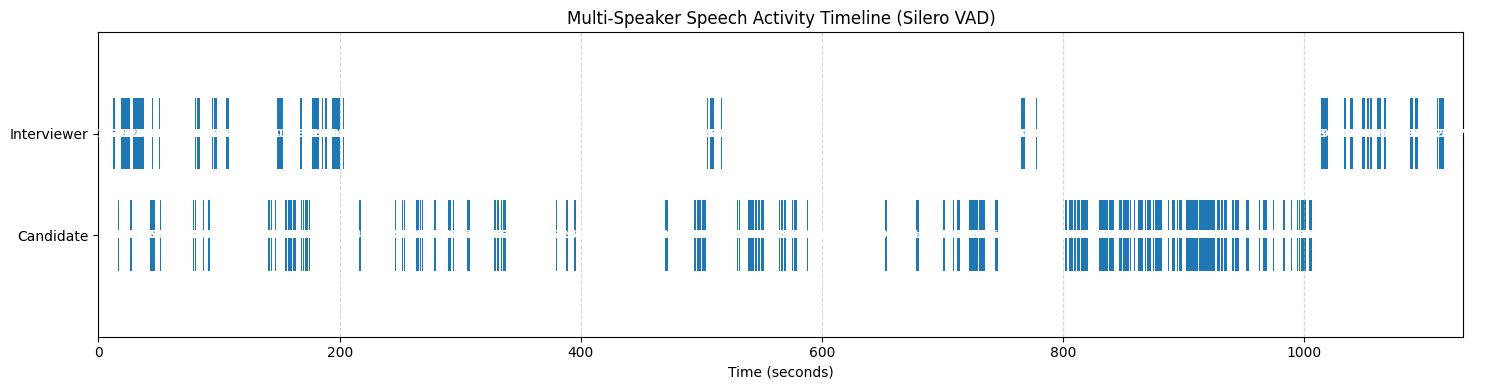

In [69]:
timestamps_2 = chunk_interview("diarization_output/sample2/")

Applying VAD on audio:  0
Processed audio:  0
Applying VAD on audio:  1
Processed audio:  1


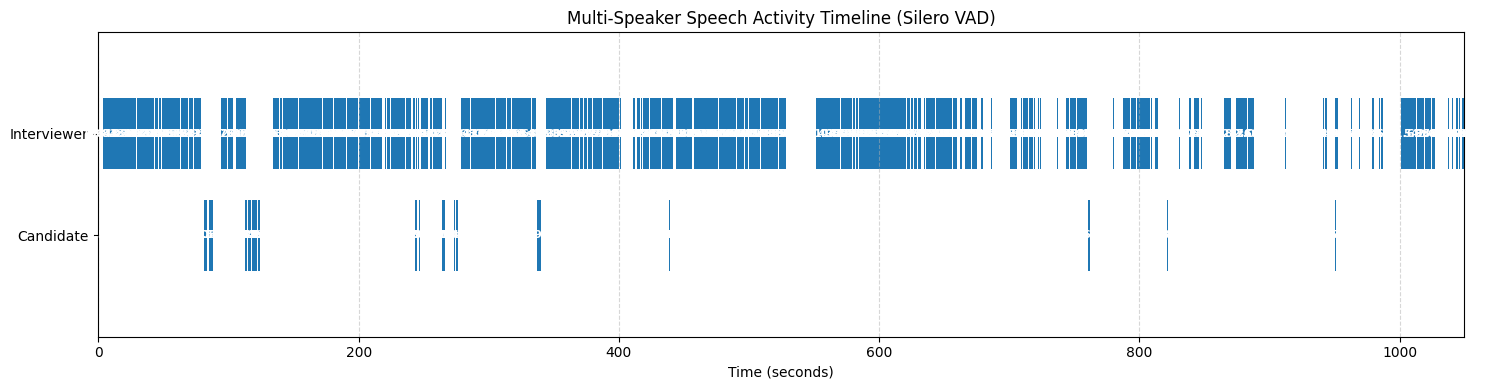

In [70]:
timestamps_3 = chunk_interview("diarization_output/sample3/")

Applying VAD on audio:  0
Processed audio:  0
Applying VAD on audio:  1
Processed audio:  1


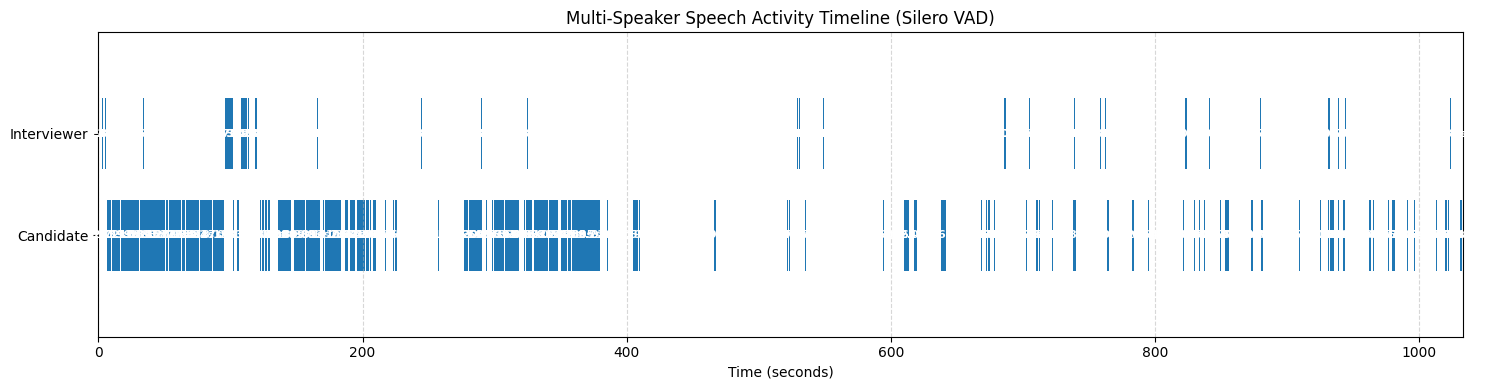

In [71]:
timestamps_4 = chunk_interview("diarization_output/sample4/")

In [36]:
timestamp_int = convert_timestamps(speech_timestamps_int)
timestamp_can = convert_timestamps(speech_timestamps_can)

## Silero VAD Iterator

In [74]:
USE_PIP = True # download model using pip package or torch.hub
USE_ONNX = False # change this to True if you want to test onnx model
if USE_ONNX:
    !pip install -q onnxruntime
if USE_PIP:
  !pip install -q silero-vad
  from silero_vad import (load_silero_vad,
                          read_audio,
                          get_speech_timestamps,
                          save_audio,
                          VADIterator,
                          collect_chunks)
  model = load_silero_vad(onnx=USE_ONNX)
else:
  model, utils = torch.hub.load(repo_or_dir='snakers4/silero-vad',
                                model='silero_vad',
                                force_reload=True,
                                onnx=USE_ONNX)

  (get_speech_timestamps,
  save_audio,
  read_audio,
  VADIterator,
  collect_chunks) = utils

In [78]:
SAMPLING_RATE=16000

In [79]:
vad_iterator = VADIterator(model, sampling_rate=SAMPLING_RATE)

In [80]:
wav = read_audio(f'data/full_audio1.wav', sampling_rate=SAMPLING_RATE)

In [85]:
# window_size_samples = 512 if SAMPLING_RATE == 16000 else 256
# for i in range(0, len(wav), window_size_samples):
#     chunk = wav[i: i+ window_size_samples]
#     if len(chunk) < window_size_samples:
#       break
#     speech_dict = vad_iterator(chunk, return_seconds=False)
#     if speech_dict:
#         print(speech_dict)
# vad_iterator.reset_states()